<hr style="height:2px;">

# Generate training data for CARE (patch extraction)

This notebook generates a paired **training dataset** for **CARE (Content-Aware Image Restoration)** models by extracting many small, corresponding image crops (“patches”) from paired **input → target** images.

It supports two modes:

- **Demo mode (default):** download a small example dataset (U2OS cells, low-SNR → high-SNR).
- **Custom mode:** point to your own paired dataset on disk.

Output: a single **`.npz`** file containing `(X, Y, XY_axes)` that you load in the **training notebook**.

### Demo dataset (what you are looking at)

The example data contains paired 2D images of **human U2OS cells**:

- **`low/`**: noisy input images (simulated low-light acquisition)
- **`GT/`**: high-SNR “ground truth” targets

The dataset is already split into:

- **`train/`**: used to generate training patches
- **`test/`**: kept for evaluation later

Because the noisy images are synthetically generated, pairs are already perfectly aligned.

More documentation is available at http://csbdeep.bioimagecomputing.com/doc/.

In [7]:
# --- Notebook setup ---

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

from tifffile import imread
from csbdeep.utils import download_and_extract_zip_file, plot_some
from csbdeep.data import RawData, create_patches, no_background_patches

### Configuration (what to edit for your own data)

For your own dataset you usually only change:

1) `USE_EXAMPLE_DATA`  
2) `DATA_ROOT` (path to your dataset root)  
3) `SOURCE_DIRS` / `TARGET_DIR` (folder names under `train/`)  
4) `AXES` (most common: `"YX"` for 2D single-channel)

Patch tuning knobs:

- `PATCH_SIZE: start with `(128, 128)` for 2D
- `N_PATCHES_PER_IMAGE`: start with `32` (increase if you have few images / very large images)
- `PATCH_FILTER_THRESHOLD`: use `0.0` to disable filtering; try `0.1–0.3` if images contain lots of background

In [8]:
# ============================================================
# CONFIG (edit this cell for a new dataset)
# ============================================================

# Toggle between demo dataset and your own data
USE_EXAMPLE_DATA = True


# ------------------------------------------------------------
# Demo dataset configuration
# ------------------------------------------------------------
EXAMPLE_URL = "http://csbdeep.bioimagecomputing.com/example_data/snr_7_binning_2.zip"

DEMO_DATA_ROOT = Path("CARE_example_data")
DEMO_SOURCE_DIRS = ["low"]
DEMO_TARGET_DIR = "GT"
DEMO_AXES = "YX"


# ------------------------------------------------------------
# Custom dataset configuration (used if USE_EXAMPLE_DATA=False)
# ------------------------------------------------------------
CUSTOM_DATA_ROOT = Path("/path/to/your/dataset")   # <-- change this
CUSTOM_SOURCE_DIRS = ["input"]                     # <-- change this
CUSTOM_TARGET_DIR = "target"                       # <-- change this
CUSTOM_AXES = "YX"                                 # <-- change if needed


# ------------------------------------------------------------
# Select configuration
# ------------------------------------------------------------
if USE_EXAMPLE_DATA:
    DATA_ROOT = DEMO_DATA_ROOT
    SOURCE_DIRS = DEMO_SOURCE_DIRS
    TARGET_DIR = DEMO_TARGET_DIR
    AXES = DEMO_AXES
    print("Using example dataset.")
else:
    DATA_ROOT = CUSTOM_DATA_ROOT
    SOURCE_DIRS = CUSTOM_SOURCE_DIRS
    TARGET_DIR = CUSTOM_TARGET_DIR
    AXES = CUSTOM_AXES
    print("Using custom dataset.")


# ------------------------------------------------------------
# Patch extraction parameters
# ------------------------------------------------------------
PATCH_SIZE = (128, 128)

# Increase if you have few images or very large images
N_PATCHES_PER_IMAGE = 32

# Background filtering:
# 0.0 disables filtering
# try 0.1–0.3 if images contain large empty regions
PATCH_FILTER_THRESHOLD = 0.0


# Output location
PATCH_DIRNAME = "train_patches"
PATCH_FILENAME = "train_patches.npz"


print("\nConfiguration:")
print("DATA_ROOT:", DATA_ROOT)
print("SOURCE_DIRS:", SOURCE_DIRS)
print("TARGET_DIR:", TARGET_DIR)
print("AXES:", AXES)

Using example dataset.

Configuration:
DATA_ROOT: CARE_example_data
SOURCE_DIRS: ['low']
TARGET_DIR: GT
AXES: YX


### Helper functions

These helpers make the notebook more robust and portable:

- resolve paths cleanly (`DATA_ROOT.resolve()`)
- locate patch directories even if a legacy name exists (e.g. `train patches`)
- print “leaf” subdirectories for sanity checks

In [9]:
def resolve_data_root(p: Path) -> Path:
    return p.expanduser().resolve()

def find_patch_dir(data_root: Path, preferred: str = "train_patches") -> Path:
    """
    Use preferred folder name if it exists, otherwise fall back to a legacy folder
    (e.g. 'train patches') if it exists, otherwise return preferred for creation.
    """
    preferred_dir = data_root / preferred
    if preferred_dir.exists():
        return preferred_dir

    legacy_candidates = [
        data_root / "train patches",   # common legacy name with space
    ]
    for c in legacy_candidates:
        if c.exists():
            return c

    return preferred_dir

def print_leaf_dirs(root: Path):
    root = root.resolve()
    leaves = []
    for p in root.rglob("*"):
        if p.is_dir():
            try:
                has_subdir = any(c.is_dir() for c in p.iterdir())
            except PermissionError:
                continue
            if not has_subdir:
                leaves.append(p)
    for p in sorted(leaves):
        print(" -", p.relative_to(root))

### Get the data (demo only)

If `USE_EXAMPLE_DATA=True`, the example dataset is downloaded and extracted into `DATA_ROOT`.

If you use your own data, set `USE_EXAMPLE_DATA=False` and make sure your folder structure matches
the expected layout (see the config cell).

In [10]:
DATA_ROOT = resolve_data_root(DATA_ROOT)

if USE_EXAMPLE_DATA:
    print("Downloading example data to:")
    print(" ", DATA_ROOT)
    download_and_extract_zip_file(
        url=EXAMPLE_URL,
        targetdir=str(DATA_ROOT),
        verbose=1,
    )

print("\nDATA_ROOT:")
print(" ", DATA_ROOT)

  /home/sagah/ISS2025/ISS_CARE/Notebooks/CARE_example_data
Files found, nothing to download.

DATA_ROOT:
  /home/sagah/ISS2025/ISS_CARE/Notebooks/CARE_example_data


### Inspect the folder structure

This prints the “leaf” directories so you can confirm that the expected
`train/low`, `train/GT`, `test/low`, `test/GT` folders exist.

In [11]:
print("Leaf subdirectories under DATA_ROOT:")
print_leaf_dirs(DATA_ROOT)

train_root = DATA_ROOT / "train"
assert train_root.exists(), f"Missing folder: {train_root}"

# check source/target folders
for sd in SOURCE_DIRS:
    assert (train_root / sd).exists(), f"Missing source folder: {train_root/sd}"
assert (train_root / TARGET_DIR).exists(), f"Missing target folder: {train_root/TARGET_DIR}"

print("\nTrain root OK:", train_root)
print("Sources:", SOURCE_DIRS, "| Target:", TARGET_DIR)

Leaf subdirectories under DATA_ROOT:
 - .ipynb_checkpoints
 - models/care_example_denoise/logs/images
 - models/care_example_denoise/logs/train
 - models/care_example_denoise/logs/validation
 - test/GT
 - test/low
 - train/GT
 - train/low
 - train_patches

Train root OK: /home/sagah/ISS2025/ISS_CARE/Notebooks/CARE_example_data/train
Sources: ['low'] | Target: GT


### Quick sanity check (one paired example)

We load one matching filename from the input and target folders to verify:

- the pairing works (same filenames exist in both folders)
- shapes are compatible
- the images look like noisy input vs clean target

Example file: img_0000.tif
Input shape: (256, 256) | Target shape: (256, 256) | AXES: YX


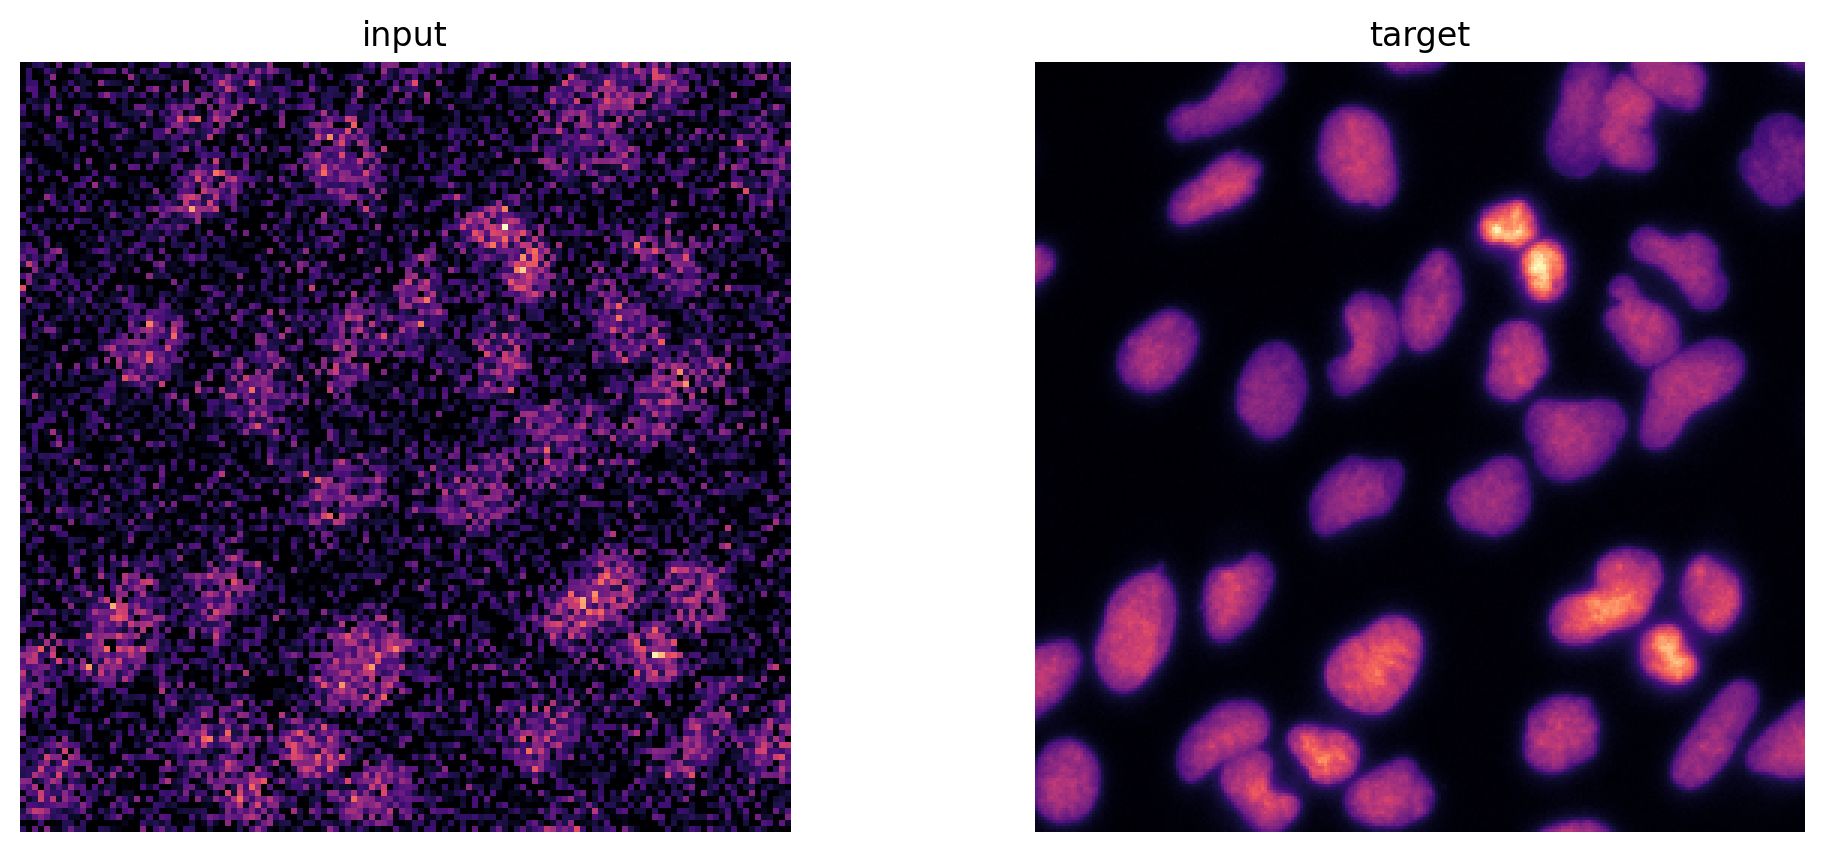

In [12]:
train_source = train_root / SOURCE_DIRS[0]
train_target = train_root / TARGET_DIR

src_files = sorted(train_source.glob("*.tif*"))
tgt_names = {p.name for p in train_target.glob("*.tif*")}

common = [p for p in src_files if p.name in tgt_names]
assert common, "No matching filenames between source and target folders."

fname = common[0].name
x = imread(train_source / fname)
y = imread(train_target / fname)

print("Example file:", fname)
print("Input shape:", x.shape, "| Target shape:", y.shape, "| AXES:", AXES)

def _norm01(a):
    a = a.astype(np.float32)
    mx = np.max(a)
    return a / mx if mx > 0 else a

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(_norm01(x), cmap="magma"); plt.title("input"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(_norm01(y), cmap="magma"); plt.title("target"); plt.axis("off")
plt.show()

### Create `RawData`

`RawData` tells CSBDeep how to iterate over paired `(input, target)` images on disk.
Here we assume:

- inputs live in `train/<source>/`
- targets live in `train/<target>/`
- filenames match between input and target

In [14]:
raw_data = RawData.from_folder(
    basepath=train_root,
    source_dirs=SOURCE_DIRS,  
    target_dir=TARGET_DIR,     
    axes=AXES,
    pattern="*.tif*",
)

print(raw_data.description)
print("Num pairs:", raw_data.size)

/home/sagah/ISS2025/ISS_CARE/Notebooks/CARE_example_data/train: target='GT', sources=['low'], axes='YX', pattern='*.tif*'
Num pairs: 2457


### Create patches (the actual training dataset)

`create_patches` samples many paired crops (“patches”) from your paired images and saves them to disk.

It returns:

- `X`: input patches (model input)
- `Y`: target patches (model target / ground truth)
- `XY_axes`: axis string for the patch arrays

#### Tuning for your own data

- `PATCH_SIZE`
  - start with **128×128** for 2D
  - increase (e.g. 256×256) if structures are large and GPU allows it
- `N_PATCHES_PER_IMAGE`
  - start with **32**
  - increase if you have few images or very large images
- `PATCH_FILTER_THRESHOLD`
  - set to **0.0** to disable filtering (safest)
  - try **0.1–0.3** if many patches are empty background  
  - if you get: *“patch_filter didn’t return any region to sample from”* → lower the threshold or set it to `0.0`

In [15]:
# Decide patch filter
# - None disables filtering
# - no_background_patches(t) keeps patches with enough foreground
patch_filter = None
if PATCH_FILTER_THRESHOLD and PATCH_FILTER_THRESHOLD > 0:
    patch_filter = no_background_patches(PATCH_FILTER_THRESHOLD)

# Patch output directory (prefer train_patches, but accept legacy folders)
patch_dir = find_patch_dir(DATA_ROOT, preferred=PATCH_DIRNAME)
patch_dir.mkdir(parents=True, exist_ok=True)

save_file = patch_dir / PATCH_FILENAME
print("Saving patches to:")
print(" ", save_file)

# Patch axes: usually spatial axes only (2D: YX, 3D: ZYX)
patch_axes = "ZYX" if "Z" in AXES else "YX"

X, Y, XY_axes = create_patches(
    raw_data=raw_data,
    patch_size=PATCH_SIZE,
    n_patches_per_image=N_PATCHES_PER_IMAGE,
    patch_axes=patch_axes,
    patch_filter=patch_filter,
    save_file=str(save_file),
    verbose=True,
)

print("\nDone.")
print("X:", X.shape, "| Y:", Y.shape, "| axes:", XY_axes)

Saving patches to:
  /home/sagah/ISS2025/ISS_CARE/Notebooks/CARE_example_data/train_patches/train_patches.npz
 2457 raw images x    1 transformations   =  2457 images
 2457 images     x   32 patches per image = 78624 patches in total
Input data:
/home/sagah/ISS2025/ISS_CARE/Notebooks/CARE_example_data/train: target='GT', sources=['low'], axes='YX', pattern='*.tif*'
Transformations:
1 x Permute axes to YX
Patch size:
128 x 128


100%|███████████████████████████████████████| 2457/2457 [00:25<00:00, 96.61it/s]


Saving data to /home/sagah/ISS2025/ISS_CARE/Notebooks/CARE_example_data/train_patches/train_patches.npz.

Done.
X: (78624, 1, 128, 128) | Y: (78624, 1, 128, 128) | axes: SCYX


### Visualize a few patch pairs

Top row: input patches (`X`)  
Bottom row: target patches (`Y`)

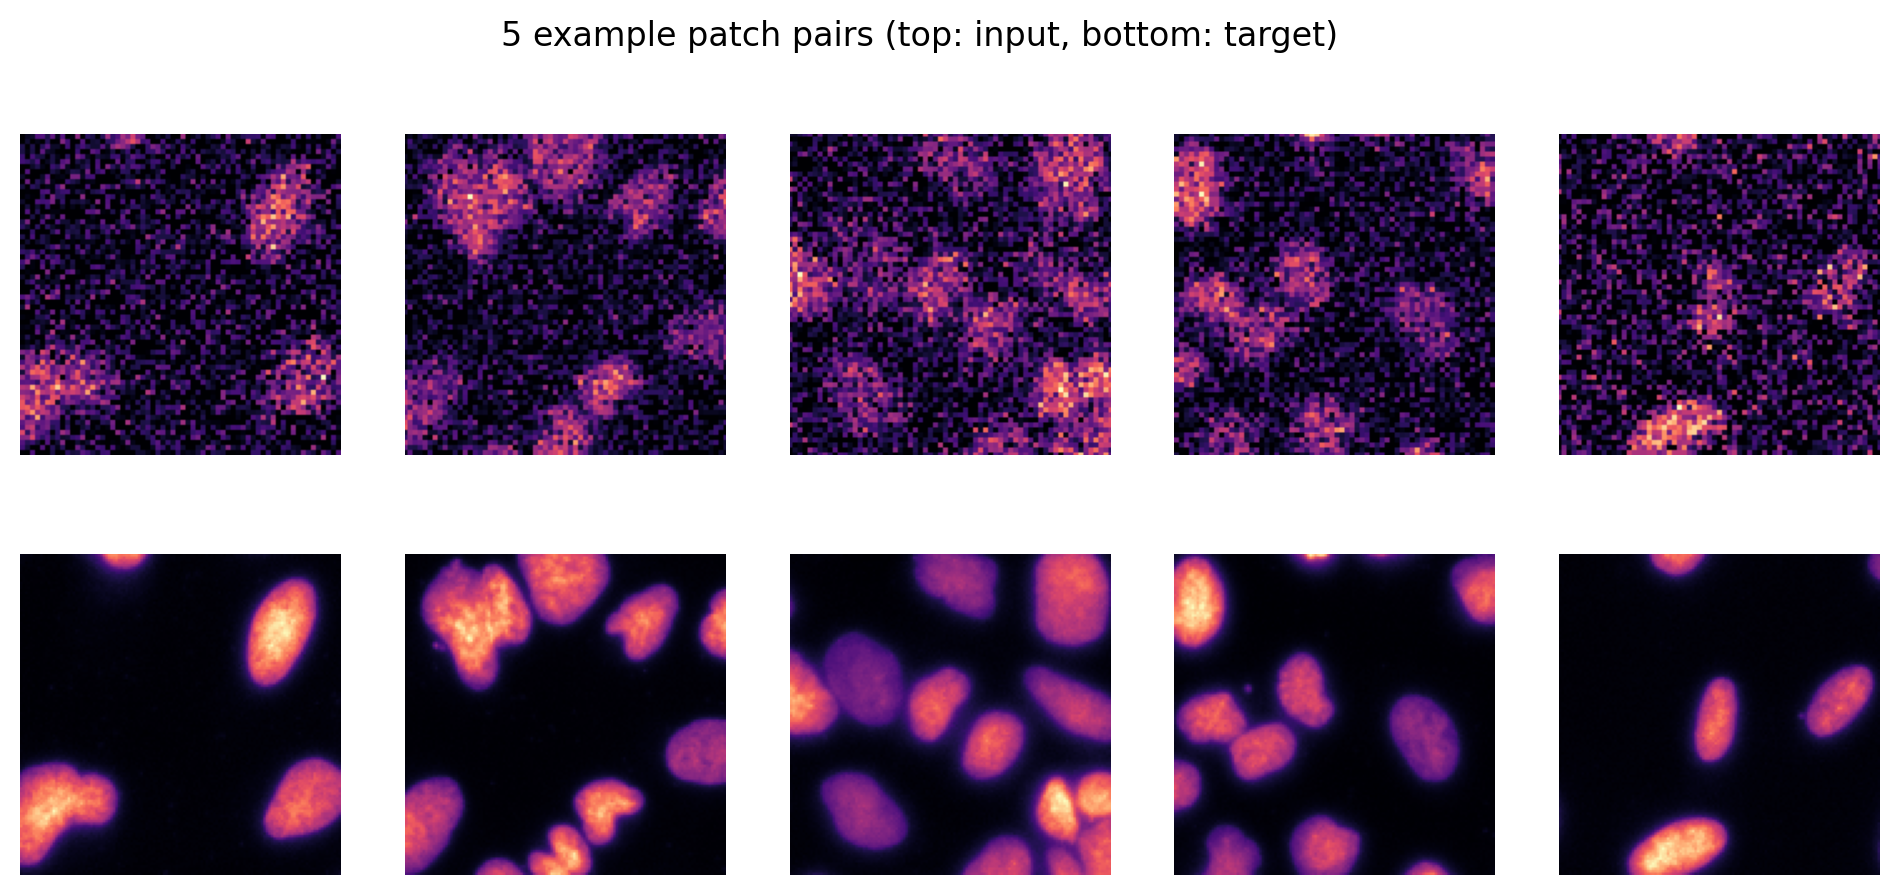

In [16]:
n_show = 5
plt.figure(figsize=(12, 5))
plot_some(X[:n_show], Y[:n_show])
plt.suptitle(f"{n_show} example patch pairs (top: input, bottom: target)")
plt.show()

### Next step

Use the saved `.npz` file in the **training notebook**.

You will load:

- `X`, `Y`, and `XY_axes`

from:

- `DATA_ROOT/<patch_dir>/<PATCH_FILENAME>`


## Using your own data (what to change)

To train CARE on a different dataset, you usually only need to edit the CONFIG cell at the top of this notebook.

1. Dataset location and structure

Update the following parameters:

CUSTOM_DATA_ROOT  – path to your dataset
CUSTOM_SOURCE_DIRS – folder(s) containing input images
CUSTOM_TARGET_DIR – folder containing target images

The simplest dataset layout uses matching filenames:
```
dataset/
    train/
        input/
            img_001.tif
            img_002.tif
        target/
            img_001.tif
            img_002.tif
```

In this case the notebook can automatically pair images using:

RawData.from_folder(...)

2. Axes definition

AXES describes the dimension order of your images.
```
2D grayscale images        → YX
2D images with channels    → YXC
3D stacks                  → ZYX
3D stacks with channels    → ZYXC
```

3. Patch extraction parameters

Training uses many small crops ("patches") extracted from the image pairs.

Important parameters:

```
PATCH_SIZE – spatial size of each crop
N_PATCHES_PER_IMAGE – number of patches sampled per image
PATCH_FILTER_THRESHOLD – optional background filtering
```

Typical starting values:
```
PATCH_SIZE = (128, 128)
N_PATCHES_PER_IMAGE = 32
PATCH_FILTER_THRESHOLD = 0.0
```

4. Workflow for a new dataset

1. Update the CONFIG cell.
2. Run this notebook to generate training patches (.npz).
3. Train the model using the training notebook.
